# Linear Regression Algorithm

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

### Importing Data and Checking out

In [5]:
# Load the USA Housing dataset from the CSV file.

HouseDF = pd.read_csv("C:\\Users\\Sakshu\\Downloads\\USA_Housing.csv")

# Display the first five rows of the dataset
HouseDF.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [6]:
# Display information about the dataset,
# including column names, data types, and non-null values.

HouseDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [7]:
# Generate descriptive statistics for the numerical columns
# such as count, mean, standard deviation, minimum, and maximum.

HouseDF.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [8]:
HouseDF.columns   #Display column names

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

## Exploratory Data Analysis 

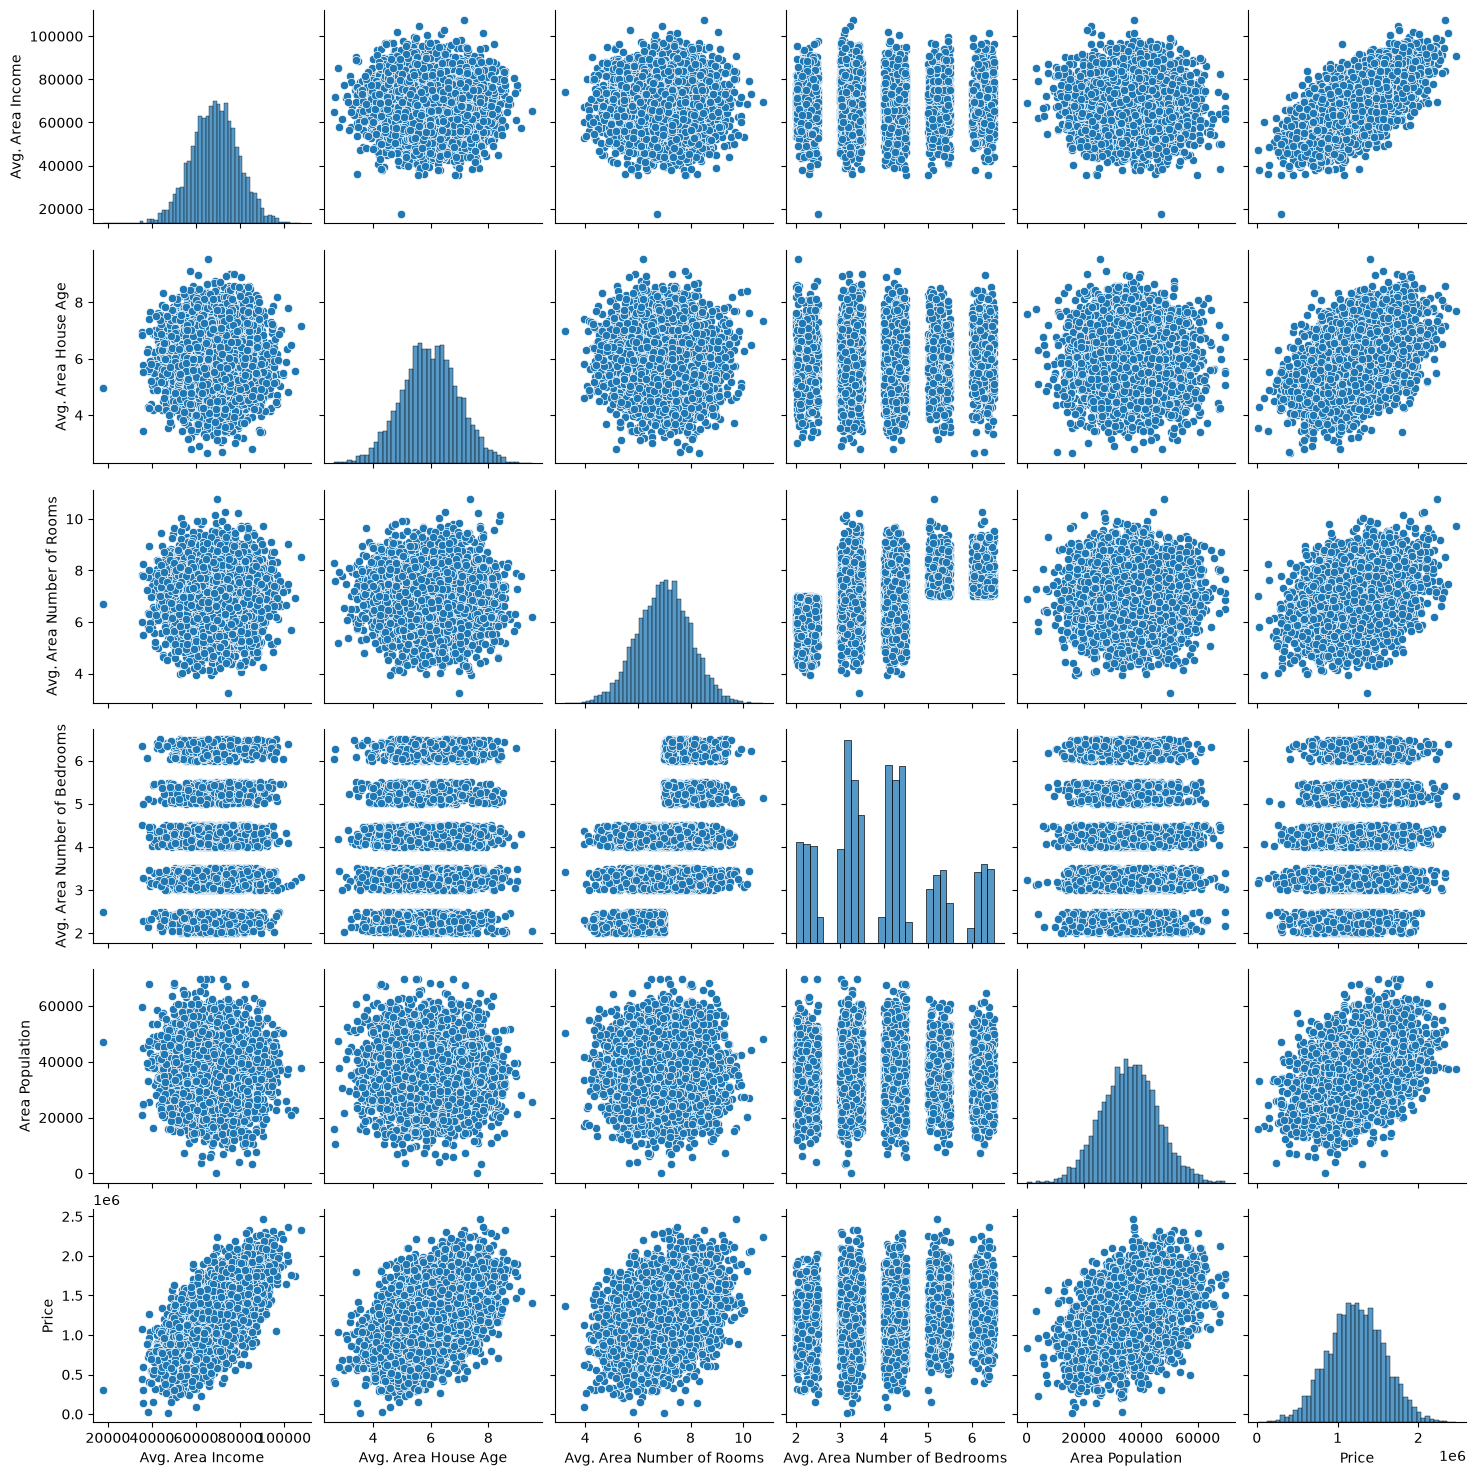

In [9]:
# Create pair plots to visualize relationships between the numerical variables in the dataset.

sns.pairplot(HouseDF)

C:\Users\Sakshu\AppData\Local\Temp\ipykernel_2796\380616116.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(HouseDF['Price'])


<Axes: xlabel='Price', ylabel='Density'>

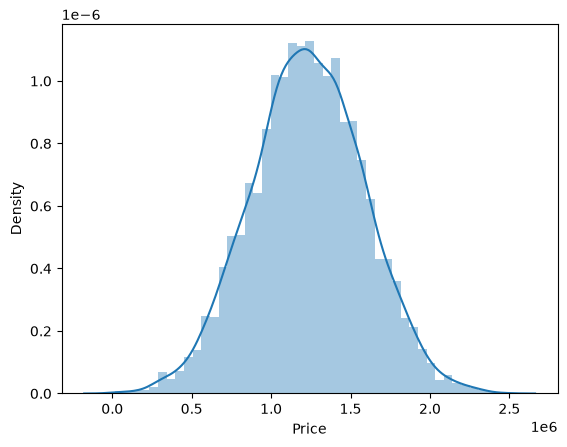

In [14]:
# Display the distribution of house prices
# using a histogram and density curve.

sns.distplot(HouseDF['Price'])

<Axes: >

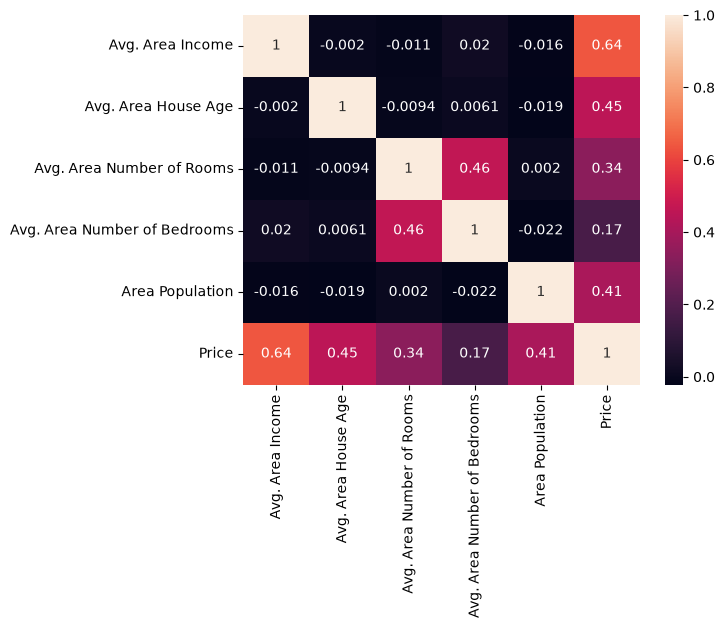

In [15]:
# Display the correlation between numerical variables using a heatmap.

sns.heatmap(HouseDF.corr(numeric_only=True), annot=True)

## Training a Linear Regression Model

### X and y List

In [16]:
# Select the independent variables (features) for the Linear Regression model

X = HouseDF[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
             'Avg. Area Number of Bedrooms', 'Area Population']]

# Select the dependent variable (target) that we want to predict
y = HouseDF['Price']

### Split Data into Train, Test

In [17]:
# 60% of the data is used for training and 40% is used for testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

## Creating and Training the LinearRegression Model

from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

## LinearRegression Model Evaluation

In [21]:
print(lm.intercept_)

-2640159.796852963


In [22]:
# Create a DataFrame to display the coefficient of each feature
# used by the Linear Regression model

coeff_df = pd.DataFrame(
    lm.coef_,
    X.columns,
    columns=['Coefficient']
)

coeff_df

,Coefficient
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


### Predictions from our Linear Regression Model

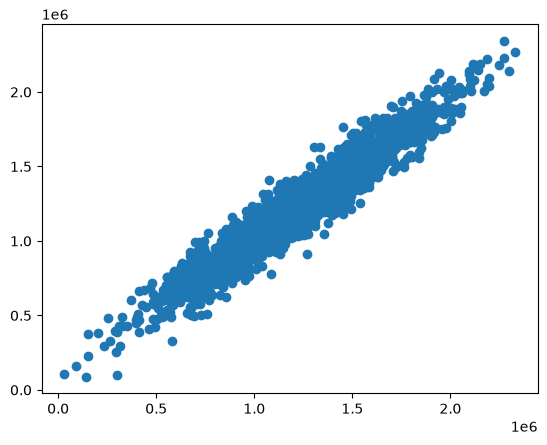

In [24]:
# Make predictions on the test data using the trained Linear Regression model
# and visualize the actual values against the predicted values

predictions = lm.predict(X_test)
plt.scatter(y_test, predictions)

C:\Users\Sakshu\AppData\Local\Temp\ipykernel_2796\3290896071.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-predictions), bins=50);


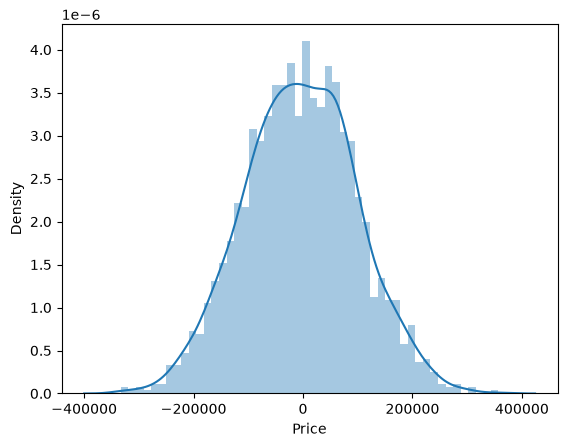

In [25]:
# Plot the distribution of prediction errors
# to check how closely the errors follow a normal distribution

sns.distplot((y_test-predictions), bins=50);

## Regression Evaluation Metrics

In [27]:
# Import evaluation metrics and calculate the Mean Absolute Error (MAE),
# Mean Squared Error (MSE), and Root Mean Squared Error (RMSE)
# to evaluate the performance of the Linear Regression model.

from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 82288.22251914945
MSE: 10460958907.208805
RMSE: 102278.82922290813
